# Fire Detection & Autonomous Response — Architecture

**D7065E — Embedded Intelligence at the Edge**

This notebook is the **design document**. It derives the system from first
principles and validates it by running a prototype: if the simulation in section 5
produces a correct result, the architecture is sound before a single line of the
service is written.

> **What was actually built, and how it differs**
>
> The design below proposes eleven processes talking over MQTT, with ThingsBoard
> for history. What shipped is **one service, `firelab`, in three layers** —
> `domain/`, `adapters/`, `app/` — beside BuildSim.
>
> The *boundaries* in this document all survived. What changed is the unit they
> are drawn in: they became module boundaries rather than container boundaries.
> Section 6 explains why, and gives the mapping from each proposed service to the
> module that holds that responsibility today.
>
> For the shipped service file by file, read `GUIDE.ipynb`. This notebook is why;
> that one is what.

**How to read it**

| Section | Question it answers |
|---|---|
| 1 | What is given, what do we build? |
| 2 | What principles govern the decomposition? |
| 3 | Which responsibilities exist and why? |
| 4 | How does one measurement flow end to end? |
| 5 | Does the design actually work? *(runnable)* |
| 6 | How is it deployed, and why one process instead of eleven? |
| 7 | What are the contracts between the parts? |
| 8 | Why is each boundary where it is? |
| 9 | How do we know it is finished and good? |


In [2]:
"""Render Mermaid source as an inline image so diagrams survive export to HTML/PDF."""

import base64
import urllib.request

from IPython.display import SVG, Markdown, display

_MERMAID_ENDPOINT = "https://mermaid.ink/svg/"


def mermaid(source: str, timeout: int = 30):
    """Display `source` as a rendered diagram, falling back to the raw code if offline."""
    payload = base64.urlsafe_b64encode(source.strip().encode()).decode()
    request = urllib.request.Request(
        _MERMAID_ENDPOINT + payload,
        headers={"User-Agent": "Mozilla/5.0"},  # the service rejects urllib's default agent
    )
    try:
        with urllib.request.urlopen(request, timeout=timeout) as response:
            display(SVG(response.read().decode()))
    except Exception as exc:
        display(Markdown(f"> Diagram not rendered ({exc}); source below.\n\n```mermaid\n{source.strip()}\n```"))


print("mermaid() ready")


mermaid() ready


## 1. What is given, what we build

BuildSim is a **state store with a 3D viewer**. It stores and renders; it does not
simulate. Its own documentation is explicit:

> "BuildSim animates the primitive but does not spread fire, diffuse gas, or apply
> sprinkler physics. A simulator must update the snapshot as the process evolves."

> "A project still needs an actuator service that checks command authority, validates
> transitions, operates the simulated lock, and reports the resulting door state."

So the division is fixed for us:

| Concern | Owner | Endpoint |
|---|---|---|
| Floor plans, rooms, walls | BuildSim | `GET /api/building` |
| Navigation graph, shortest path | BuildSim | `GET /api/graph`, `GET /api/graph/route` |
| Rendering fire, smoke, sprinkler | BuildSim | `PUT /api/effects` |
| Room colouring / heatmap | BuildSim | `PUT /api/room-layers` |
| Occupant rendering | BuildSim | `PUT /api/entities` |
| Highlights, alerts, route display | BuildSim | `PUT /api/sessions/{id}/...` |
| Door identity and lock state | BuildSim (storage only) | `GET/PUT /api/doors` |
| **Fire growth and spread** | **us** | — |
| **Sensor behaviour** | **us** | — |
| **Detection / ML** | **us** | — |
| **Response policy** | **us** | — |
| **Actuation and interlocks** | **us** | — |
| **Occupant movement** | **us** | — |
| **History and dashboards** | ThingsBoard | — |

Everything in bold is a process we write. Nothing above requires modifying
BuildSim, and we never will.


## 2. Design principles

Three principles, applied at three different scales.

### 2.1 Separation of concerns — three levels

| Level | Unit | Separated by |
|---|---|---|
| System | container | responsibility |
| Service | layer | purity — the domain never performs I/O |
| Module | function / class | one reason to change |

Most projects do level 1 only. Doing all three is the difference between a system
that *works* and one that can be *defended*.

### 2.2 Single responsibility — the real test

Not "what does this do" but **"what single change would force me to edit it?"**
If two unrelated changes touch the same file, that file has two responsibilities.

### 2.3 The dependency rule

Arrows point inward. Domain modules import only the standard library.

```
main.py  →  adapters  →  ports  ←  domain
```

The practical test: **every domain module must be importable and fully testable
with no broker, no database, and no BuildSim running.** This notebook is proof —
it imports nothing but the standard library and matplotlib.


## 3. Service map

Eleven services, grouped into five planes. Each plane has a distinct kind of
responsibility, which is what makes the system explainable in one breath:

> *The world produces truth, sensing degrades it, intelligence interprets it,
> action changes it, presentation shows it.*

Read the names below as **responsibilities, not processes**. This is the
decomposition; section 6 covers how it was packaged, and the responsibility table
after the diagram names the module each one lives in today. Mosquitto and
ThingsBoard appear because they were designed in — neither shipped, and section 6
says what replaced them.


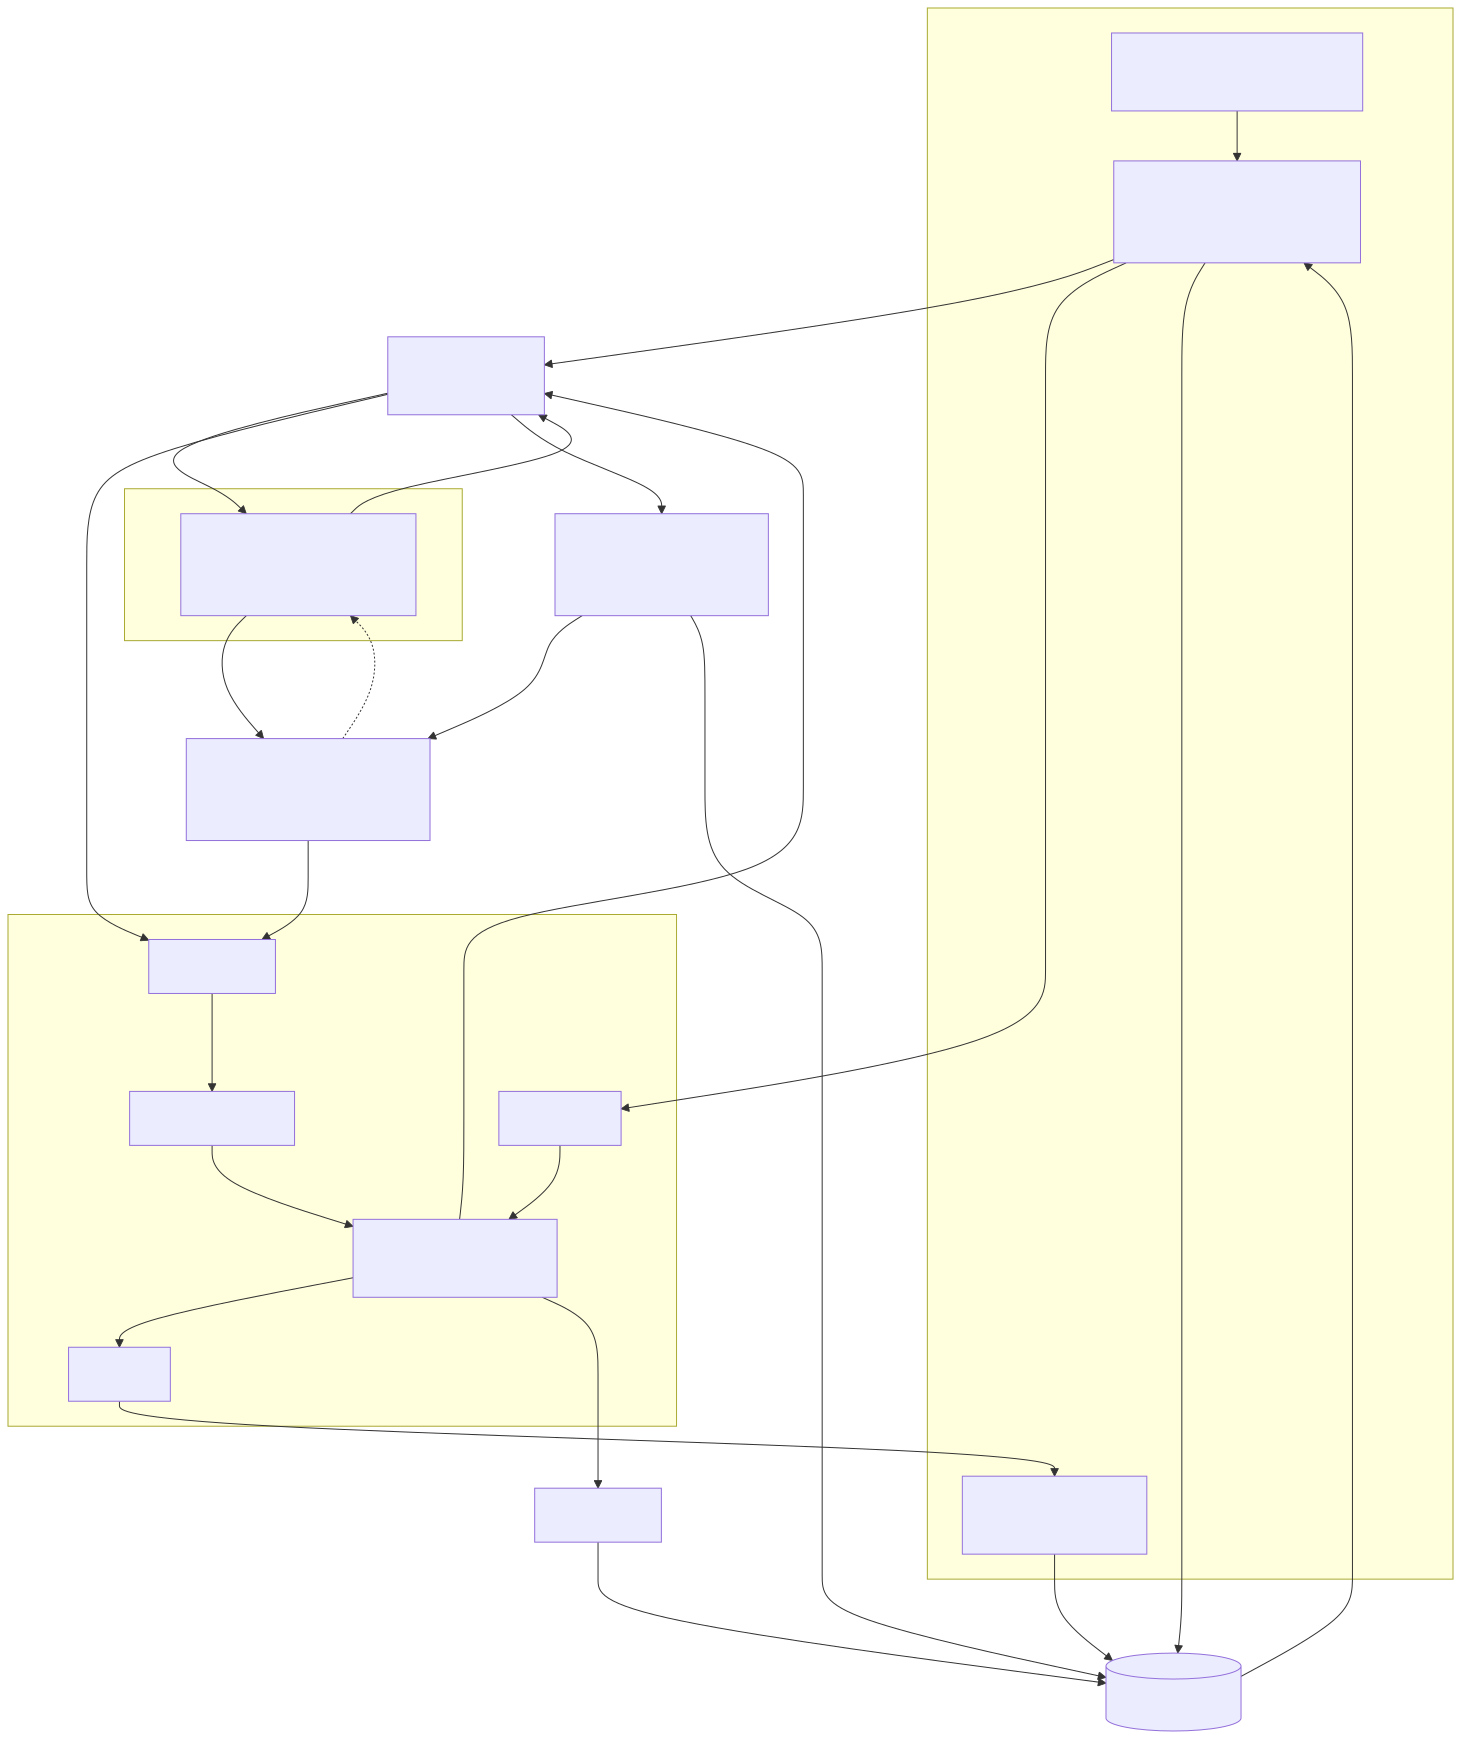

In [3]:
SERVICE_MAP = """
flowchart TB
    subgraph W["WORLD — truth"]
        SCN["scenario<br/>scripts events, emits labels"]
        FIRE["firephysics<br/>HRR, heat, smoke, CO<br/>spread across room graph"]
        EVAC["evacuation<br/>moves occupants"]
    end
    subgraph S["SENSING"]
        SENS["sensors<br/>smoke, CO, temperature<br/>lag, noise, bias, faults"]
    end
    MQ["MOSQUITTO<br/>internal bus"]
    TB["THINGSBOARD :8080<br/>devices, telemetry, history<br/>dashboards, alarms"]
    subgraph I["INTELLIGENCE"]
        FEAT["featurizer"]
        DET["detector — ML"]
        PRED["predictor"]
        ROUTE["router"]
        AGENT["agent<br/>alarm state machine"]
    end
    ACTU["actuators<br/>sprinklers + fire doors<br/>fail-safe interlocks"]
    VIZ["visualizer"]
    BS[("BUILDSIM :9090")]

    SCN --> FIRE
    FIRE -->|truth| MQ
    MQ --> SENS
    SENS -->|telemetry| MQ
    SENS -->|v1/gateway/telemetry| TB
    TB -.->|shared attributes<br/>config + faults| SENS
    MQ --> FEAT --> DET --> AGENT
    FIRE --> PRED --> AGENT
    AGENT --> ROUTE --> EVAC
    AGENT -->|command| MQ
    MQ --> ACTU
    ACTU -->|state| TB
    ACTU -->|PUT actuators + doors| BS
    BS -->|GET doors + actuators<br/>CLOSES THE LOOP| FIRE
    FIRE -->|room-layers, effects| BS
    EVAC -->|entities| BS
    AGENT --> VIZ -->|highlights, alerts, route| BS
    TB -->|history export| FEAT
"""

mermaid(SERVICE_MAP)


### Responsibility table

The third column is the honest part: it names where each responsibility ended up
once the eleven processes were collapsed into one service. The reasons to change
did not move — only the deployment unit did.

| Service | Sole responsibility | Its one reason to change | Where it lives now |
|---|---|---|---|
| `scenario` | script events, emit ground-truth labels | a new scenario type is added | `domain/sources.py`, `app/engine/scenario.py`, `app/presets.py` |
| `firephysics` | evolve heat, smoke, CO across the room graph | the fire model changes | `domain/world.py`, `domain/physics.py`, driven by `app/engine/truth.py` |
| `evacuation` | move occupants along assigned routes | crowd dynamics change | `domain/roles.py`, `domain/occupants.py`, `app/evacuation.py` |
| `sensors` | turn truth into imperfect device readings | device characteristics change | `domain/sensing.py`, installed by `app/engine/devices.py` |
| `featurizer` | window telemetry into feature vectors | the feature set changes | `domain/features.py` |
| `detector` | estimate P(fire) per room | the ML model changes | `domain/detector.py` |
| `predictor` | forecast spread and time-to-untenable | the spread model changes | `domain/tenability.py` — the consequence half only; no spread forecast shipped |
| `router` | compute evacuation paths | the routing objective changes | `app/evacuation.py`, `adapters/exits.py` — the search itself is BuildSim's |
| `agent` | run the alarm state machine, issue commands | the response policy changes | `domain/agent.py`, driven by `app/engine/intelligence.py` |
| `actuators` | validate and apply commands, report state | actuator hardware changes | `domain/interlocks.py`, `app/engine/actuation.py` |
| `visualizer` | paint highlights, alerts, routes | presentation changes | `adapters/publisher/` |

Two of these are worth flagging rather than glossing over:

- **`predictor` was not built.** `domain/tenability.py` answers *is this room still
  escapable, and who is standing in it* — the consequence of the fire, not a
  forecast of where it goes next. The spread forecast remains future work.
- **`router` is thinner than designed.** Path search belongs to BuildSim's
  walkable graph, so what we kept is exit selection and the walking, not the
  search.

Every part has the same internal shape:

```
adapter in  →  pure core  →  adapter out
```

Uniformity is the point. Eleven components that look alike are far easier to
defend than five clever ones that each look different — and it is what made
collapsing them into one process a packaging decision rather than a rewrite.


## 3b. Reading the diagram, arrow by arrow

The map above is dense. This section walks it in plain language, in the order a
single fire actually travels through the system. Read it once and the rest of the
notebook is just detail.

### The one rule

Four zones, each with a different relationship to *truth*:

| Zone | Knows | Never sees |
|---|---|---|
| **WORLD** | the truth | any sensor reading |
| **SENSING** | the truth, but corrupts it | any decision |
| **INTELLIGENCE** | only readings | the truth |
| **ACTUATION** | commands | why they were issued |

If a component ever appears in two zones, the design has failed. That single rule
generates every boundary in the diagram.

---

### Phase 1 — the world produces truth

**`SCN → FIRE`  the scenario starts the event.**
`scenario` decides *what happens and when*: fire ignites in A109 at t = 120 s,
cooking starts in A111 at t = 90 s. It also emits **ground-truth labels** — this
room is genuinely burning, that one is not. Those labels are used only to train the
detector offline and to score it afterwards. They never enter INTELLIGENCE at run
time.

**`FIRE -->|truth| MQ`  physics publishes what is real.**
`firephysics` owns the real temperature, smoke density and CO in every room. Each
tick it advances $t^2$ growth, relaxes towards equilibrium, and diffuses to
neighbours across BuildSim's adjacency graph. It publishes truth to Mosquitto —
and **nobody in INTELLIGENCE subscribes to that topic.**

---

### Phase 2 — sensing degrades it

**`MQ → SENS`  sensors are the only subscriber to truth.**
`sensors` is the gateway for *all* devices — one process holding many emulated
detectors, not one process per sensor. Each device applies its own corruption
chain:

```
lag → calibration bias → noise → quantisation → clamp → fault → sampling interval
```

This is the exact boundary where truth becomes observation.

**`SENS` publishes twice — and the duplication is deliberate:**

| Arrow | Destination | Why |
|---|---|---|
| `SENS -->\|telemetry\| MQ` | Mosquitto | so your own services can consume it |
| `SENS -->\|v1/gateway/telemetry\| TB` | ThingsBoard | storage, history, dashboards |

Two arrows are needed because ThingsBoard's MQTT is **not a general broker**. A
client may publish only its own data on `v1/devices/me/...` or `v1/gateway/...`; it
cannot subscribe to another device's telemetry. Mosquitto therefore stays as the
process-to-process bus.

**`TB -.-> SENS`  configuration flows back.**
The dashed line is ThingsBoard **shared attributes**. Change a sensor's noise level
or inject a fault by editing an attribute in the UI, and the sensor service picks it
up live. That is how a failing detector is demonstrated without restarting anything.

---

### Phase 3 — intelligence interprets it

**`MQ → FEAT → DET → AGENT`  the chain from readings to a decision.**

| Service | Question it answers |
|---|---|
| `featurizer` | what does the model *see*? — smoke level, rate of rise, temperature rise, CO level, CO-to-smoke ratio, neighbour agreement |
| `detector` | is there a fire? — one probability per room |
| `agent` | what do we *do*? — `NORMAL → INVESTIGATING → PRE_ALARM → CONFIRMED → SUPPRESSED` |

Splitting *detection* from *response* is what makes the ML component swappable: the
fusion rule and the trained model are interchangeable behind one interface, and the
state machine never notices.

**`TB -->|history export| FEAT`  the training path.**
This is the only reason ThingsBoard stores history. Export accumulated telemetry,
join it against `scenario` labels, train offline, drop the model into `detector`.
Training never happens online.

**`FIRE → PRED → AGENT`  the one deliberate exception.**
`predictor` reads physics truth directly to forecast where the fire will be in 60 s.
This *is* a conscious violation of the truth boundary. Defend it in the report as an
**oracle predictor** — the upper bound on what forecasting could achieve — or replace
it with a reading-fed predictor if you want the architecture pure. Either answer is
defensible; pretending the violation is not there is not.

---

### Phase 4 — action changes it

**`AGENT -->|command| MQ → ACTU`  the agent commands, it does not act.**
The agent issues a *command*. It never writes actuator state. This is required
directly by `docs/api/doors.md`:

> "A project still needs an actuator service that checks command authority, validates
> transitions, operates the simulated lock, and reports the resulting door state."

**`ACTU`  where safety lives.**
`actuators` validates every command against interlocks the agent **cannot override**:

- sprinklers require heat corroboration, not smoke alone
- fire doors fail unlocked
- a room on an active escape route may not be sealed

Because the rules live here and not in the agent, a buggy or mistrained agent still
cannot trap someone.

**`BS -->|GET doors + actuators| FIRE`  ← the most important arrow in the diagram.**
Physics reads actuator and door state back from BuildSim, so an active sprinkler
lowers the heat release rate and a closed fire door slows diffusion to the neighbour.

> Without this arrow you have a **dashboard**.
> With it you have a **control system** — the decision changes the next measurement.

---

### Phase 5 — presentation shows it

Three separate writers into BuildSim, and the separation is the point:

| Writer | Writes | Represents |
|---|---|---|
| `FIRE` | room-layers, effects | what is physically **true** |
| `EVAC` | entities | where people **are** |
| `VIZ` | highlights, alerts, route | what the system **believes** |

Keeping truth apart from belief is what lets the demo show the system being *wrong*:
a red highlight on a room that is not burning is a false positive you can point at
on screen.

**`AGENT → ROUTE → EVAC`  the containment dilemma, made visible.**
The agent decides evacuation is needed; `router` asks BuildSim for paths that already
exclude locked and blocked doors; `evacuation` moves occupants along them. Because
routing consults live door state, sealing A109 *provably* traps its occupant — which
is the containment-versus-evacuation conflict this project exists to study.

---

### Summary — the system is three loops

| Loop | Path | Built in |
|---|---|---|
| **Control** | physics → sensors → featurizer → detector → agent → actuators → BuildSim → physics | weeks 2–3, one room |
| **Learning** | scenario labels + ThingsBoard history → offline training → detector | weeks 4–5 |
| **Evacuation** | agent → router → BuildSim graph → occupants → door state | weeks 6–7 |

Only the control loop must exist for the system to be a control system at all. The
rest of this notebook implements it and runs it.


## 4. The flow, step by step

One ignition event, traced from cause to consequence and back again.

The *Mechanism* column is written in the design's terms — published topics and
separate services. Every step still happens, in this order, but as calls inside a
single tick of `app/engine/core.py`. Steps 2–4 are `truth.advance`, step 6 is
`truth.sense`, steps 8–11 are `intelligence.think`, and step 12 is
`actuation.apply`.

| # | Step | Actor | Mechanism |
|---|---|---|---|
| 1 | A source ignites in room A109 | `scenario` | publishes `scenario/label` |
| 2 | True heat, smoke and CO rise | `firephysics` | $t^2$ growth model |
| 3 | Smoke leaks to adjacent rooms | `firephysics` | adjacency graph, door-gated |
| 4 | Truth is published | `firephysics` | `truth/level0/A109/smoke` |
| 5 | Truth is rendered | `firephysics` | `PUT /api/room-layers`, `PUT /api/effects` |
| 6 | A detector observes it imperfectly | `sensors` | lag, bias, noise, quantise, fault |
| 7 | Reading is published twice | `sensors` | `telemetry/...` **and** ThingsBoard |
| 8 | Readings become features | `featurizer` | sliding windows, cross-modal ratios |
| 9 | Features become a probability | `detector` | anomaly model + fusion |
| 10 | Probability drives a state machine | `agent` | NORMAL → … → CONFIRMED |
| 11 | The agent issues commands | `agent` | `command/sprinkler-A109` |
| 12 | Commands are checked, then applied | `actuators` | interlocks, then `PUT /api/actuators/...` |
| 13 | **Physics reads actuator state back** | `firephysics` | `GET /api/doors`, `GET /api/equipment` |
| 14 | Suppression changes the next truth | `firephysics` | **the loop is closed** |
| 15 | Routes are replanned around hazard | `router` → `evacuation` | `GET /api/graph/route` |
| 16 | Operator sees the incident | `visualizer` | highlights, alerts, route display |

**Step 13 is the one that must not be forgotten.** Without it the agent's commands
can never affect the next simulated measurement, and the whole system degenerates
into an expensive data generator.

In one process step 13 costs nothing — actuation writes `space.sprinkler` and the
next call to `physics.step` reads it — which is a fair part of why the collapse
was worth making. Across eleven services it was a round trip through BuildSim on
every tick.

The rest of this notebook implements steps 1–14 and runs them.


## 5. The design, executed

Everything below is pure: standard library only, no network, no clock, no config.
This is the prototype the shipped `domain/` grew from, and it still runs on its
own — which is the claim being tested.

It is not a copy of the shipped code. Three things were renamed or reshaped on
the way in, and knowing which saves confusion when reading both:

| Here | In `domain/` | Why |
|---|---|---|
| `fire_flaming`, `fire_smouldering` | `flaming`, `smouldering` | the `fire_` prefix stopped earning its keep once `REAL` named the real ones |
| `Room` + `RoomState` | one `Space` in `world.py` | the split gained nothing; every caller wanted both halves |
| `edges` as `(a, b, door_id)` tuples | `Coupling` in `world.py` | it needed a name once the walkable graph started producing them |

The physics, the transducer chain, the feature set and the state machine are
otherwise the same model.


In [4]:
from dataclasses import dataclass, replace
from math import exp
import random

T_OUT = 20.0          # outdoor / baseline temperature, degrees C
DT = 1.0              # simulation step, seconds
HORIZON = 900         # seconds


def approach(x: float, target: float, tau: float, dt: float) -> float:
    """First-order lag: the single dynamic used everywhere in this model."""
    return target + (x - target) * exp(-dt / tau)


print("approach(20 -> 45, tau=120s):",
      [round(approach(20, 45, 120, t), 1) for t in (0, 60, 120, 300, 600)])


approach(20 -> 45, tau=120s): [20.0, 29.8, 35.8, 42.9, 44.8]


### Step 1 — `scenario`: sources and their signatures

A fire is distinguishable from cooking only because the **multi-modal pattern**
differs. So each source declares its own contribution to heat, smoke and CO.

Flaming fire growth follows the standard $t^2$ law:

$$Q(t) = \alpha t^2, \qquad
\alpha \in \{0.0029,\ 0.0117,\ 0.0469,\ 0.1876\}\ \mathrm{kW/s^2}$$

for slow, medium, fast and ultrafast growth respectively.

The discriminating quantity is the **CO-to-smoke ratio** together with **heat**:

| Source | Heat | Smoke | CO | CO/smoke |
|---|---|---|---|---|
| Flaming fire | high | high | high | very high |
| Smouldering fire | very low | high | very high | very high |
| Cooking | low | medium | low | low |
| Dust | none | brief pulse | none | zero |
| Steam | none | brief pulse | none | zero |

No single sensor separates these. That is precisely why the detector fuses three
modalities plus the neighbouring rooms — and why the project is worth doing.


In [5]:
ALPHA = {"slow": 0.0029, "medium": 0.0117, "fast": 0.0469, "ultrafast": 0.1876}


@dataclass(frozen=True)
class Source:
    kind: str            # ground-truth label, published on scenario/label
    room: str
    t_start: float
    growth: str = "medium"


def bump(t, rise, fall):
    """Rise then decay - used for transient nuisances."""
    if t <= 0:
        return 0.0
    return (1 - exp(-t / rise)) * exp(-max(0.0, t - 3 * rise) / fall)


def emission(src: Source, t: float):
    """Return (heat_kW, smoke_equilibrium_1/m, co_equilibrium_ppm) at time t.

    Equilibrium form keeps every source expressible in one line and lets the
    room dynamics own all the time constants.
    """
    e = t - src.t_start
    if e <= 0:
        return 0.0, 0.0, 0.0

    if src.kind == "fire_flaming":
        q = min(ALPHA[src.growth] * e * e, 2000.0)
        return q, 0.0020 * q, 3.0 * q

    if src.kind == "fire_smouldering":
        f = 1 - exp(-e / 300)
        return 8.0 * f, 0.25 * f, 400.0 * f

    if src.kind == "cooking":
        f = bump(e, 120, 400)
        return 4.0 * f, 0.12 * f, 8.0 * f

    if src.kind == "dust":
        f = bump(e, 15, 60)
        return 0.0, 0.15 * f, 0.0

    if src.kind == "steam":
        f = bump(e, 20, 90)
        return 0.0, 0.20 * f, 0.0

    return 0.0, 0.0, 0.0


for kind in ("fire_flaming", "fire_smouldering", "cooking", "dust"):
    s = Source(kind, "A109", 0.0)
    h, sm, co = emission(s, 240)
    ratio = co / sm if sm > 1e-9 else 0.0
    print(f"{kind:18s} @240s  heat={h:7.1f} kW  smoke={sm:5.3f} 1/m  "
          f"CO={co:7.1f} ppm  CO/smoke={ratio:7.0f}")


fire_flaming       @240s  heat=  673.9 kW  smoke=1.348 1/m  CO= 2021.8 ppm  CO/smoke=   1500
fire_smouldering   @240s  heat=    4.4 kW  smoke=0.138 1/m  CO=  220.3 ppm  CO/smoke=   1600
cooking            @240s  heat=    3.5 kW  smoke=0.104 1/m  CO=    6.9 ppm  CO/smoke=     67
dust               @240s  heat=    0.0 kW  smoke=0.006 1/m  CO=    0.0 ppm  CO/smoke=      0


### Step 2 — `firephysics`: room dynamics

Each room holds four true state variables. They evolve toward the equilibrium the
source demands, with the room's own time constants.

$$T \leftarrow \mathrm{approach}\!\left(T,\; T_{out} + \frac{Q}{UA},\; \tau_T,\; \Delta t\right)$$

Sprinkler suppression multiplies the heat release rate — it acts on the **room**,
never on the sensor. That is what makes step 13 meaningful.


In [6]:
@dataclass(frozen=True)
class Room:
    name: str
    ua: float = 4.0       # kW/K   lumped heat loss for a small compartment
    tau_t: float = 90.0   # s      thermal time constant
    tau_s: float = 45.0   # s      smoke / gas mixing time constant


@dataclass
class RoomState:
    temp: float = T_OUT
    smoke: float = 0.0    # optical density, 1/m   (visibility ~ 3/smoke)
    co: float = 0.0       # ppm
    heat: float = 0.0     # kW


def advance(st: RoomState, room: Room, emis, dt: float, suppressed: bool) -> RoomState:
    """Pure: previous truth + source + suppression -> next truth."""
    heat, smoke_eq, co_eq = emis
    if suppressed:
        heat *= 0.25          # sprinkler knocks down the heat release rate
        smoke_eq *= 0.40
    return RoomState(
        temp=approach(st.temp, T_OUT + heat / room.ua, room.tau_t, dt),
        smoke=approach(st.smoke, smoke_eq, room.tau_s, dt),
        co=approach(st.co, co_eq, room.tau_s, dt),
        heat=heat,
    )


### Step 3 — spread across the room graph, gated by doors

Adjacency comes from `GET /api/graph?type=adjacency`. Door state comes from
`GET /api/doors`. The gate coefficient is where the two meet:

$$\dot{D_j} \mathrel{+}= k\, g_{ij}\, (D_i - D_j), \qquad
g_{ij} = \begin{cases}
1.00 & \text{open} \\
0.10 & \text{closed} \\
0.02 & \text{closed, fire-rated}
\end{cases}$$

**This creates the central design tension of the project.** Closing a fire door
contains the smoke *and* removes its entry node from evacuation routes. The agent
must trade containment against egress, room by room, as the fire grows.


In [7]:
GATE = {"open": 1.00, "closed": 0.10, "fire_rated": 0.02}
DIFF = {"temp": 0.004, "smoke": 0.010, "co": 0.010}   # per second, per unit gate


def diffuse(states: dict, edges: list, doors: dict, dt: float) -> dict:
    """Pure: exchange heat, smoke and CO across every adjacency."""
    out = {k: replace(v) for k, v in states.items()}
    for a, b, door_id in edges:
        g = GATE[doors.get(door_id, "open")]
        for field in ("temp", "smoke", "co"):
            gradient = getattr(states[a], field) - getattr(states[b], field)
            flux = gradient * g * DIFF[field] * dt
            setattr(out[a], field, getattr(out[a], field) - flux)
            setattr(out[b], field, getattr(out[b], field) + flux)
    return out


### Step 6 — `sensors`: the transducer chain

The room has a true smoke density whether or not a detector is installed. The
sensor is a separate, flawed **observer** of that truth.

Eight ordered stages turn truth into a reading:

| # | Stage | Models |
|---|---|---|
| 1 | lag | chamber / thermal mass response |
| 2 | bias + drift | calibration error, ageing |
| 3 | noise | electrical and quantisation noise |
| 4 | quantise | ADC resolution |
| 5 | clamp | sensor range saturation |
| 6 | fault | stuck, dropout, spike, drift |
| 7 | sample gate | the device only reports every `interval` seconds |
| 8 | deadband | do not transmit insignificant changes |

Bias is drawn **once per device**, at construction. That is why two detectors in
the same room disagree, and why device state — not deployment — is what has to be
per-sensor. One process hosts them all.


In [8]:
@dataclass
class Sensor:
    id: str
    room: str
    quantity: str          # smoke | co | temp
    tau: float             # response time constant, s
    sigma: float           # noise standard deviation
    resolution: float      # ADC step
    lo: float
    hi: float
    interval: float        # sampling period, s
    deadband: float
    bias: float = 0.0
    filtered: float = 0.0
    next_sample: float = 0.0
    last_sent: float = None
    fault: str = "none"    # none | stuck | dropout | spike | drift
    drift: float = 0.0
    started: bool = False

    def observe(self, truth: float, t: float, rng: random.Random):
        # 1. lag - a real device powers on already reading its environment
        if not self.started:
            self.filtered, self.started = truth, True
        self.filtered = approach(self.filtered, truth, self.tau, DT)

        # 7. sample gate - most ticks return nothing at all
        if t < self.next_sample:
            return None
        self.next_sample = t + self.interval

        if self.fault == "dropout":
            return None

        # 2. bias and drift
        self.drift += 1e-5 * self.interval
        v = self.filtered + self.bias + self.drift

        # 3. noise
        v += rng.gauss(0.0, self.sigma)

        # 6. fault injection
        if self.fault == "stuck":
            v = self.last_sent if self.last_sent is not None else v
        elif self.fault == "spike" and rng.random() < 0.05:
            v += self.hi * 0.5

        # 4 and 5. quantise, then clamp to range
        v = round(v / self.resolution) * self.resolution
        v = min(max(v, self.lo), self.hi)

        # 8. deadband
        if self.last_sent is not None and abs(v - self.last_sent) < self.deadband:
            return None
        self.last_sent = v
        return v


def make_sensors(room: str, rng: random.Random):
    """Datasheet-flavoured parameters, one object per physical device."""
    return [
        Sensor(f"smoke-{room}", room, "smoke", tau=20, sigma=0.010,
               resolution=0.005, lo=0, hi=3.0, interval=5, deadband=0.005,
               bias=rng.gauss(0, 0.01)),
        Sensor(f"co-{room}", room, "co", tau=40, sigma=8.0,
               resolution=1.0, lo=0, hi=2000, interval=10, deadband=2.0,
               bias=rng.gauss(0, 15)),
        Sensor(f"temp-{room}", room, "temp", tau=60, sigma=0.05,
               resolution=0.1, lo=-40, hi=125, interval=10, deadband=0.1,
               bias=rng.gauss(0, 0.3)),
    ]


### Step 8 — `featurizer`: what the model actually sees

Raw values are weak. Features are strong. Five of them, each chosen because it
separates a specific confusable pair:

| Feature | Separates |
|---|---|
| `smoke` level | anything from nothing |
| `smoke_rate` (per minute) | dust pulses from developing fires |
| `temp_rise` above baseline | flaming fire from cooking and smoulder |
| `co` level | combustion from steam and dust |
| `co_per_smoke` | combustion from *smoky* non-combustion |
| `neighbour_smoke` | a real event from a single-sensor fault |

That last one is the reason the system is multi-sensor at all: a faulty detector
moves alone, whereas a real fire moves its neighbours too. Note that neighbours
are consulted through their **readings** — the intelligence plane never has access
to physical truth.


In [8]:
from collections import deque


class Featurizer:
    """Sliding window over the readings of one room."""

    def __init__(self, window=60):
        self.window = window
        self.hist = deque()          # (t, smoke)
        self.latest = {}

    def update(self, t, quantity, value):
        self.latest[quantity] = value
        if quantity == "smoke":
            self.hist.append((t, value))
            while self.hist and t - self.hist[0][0] > self.window:
                self.hist.popleft()

    def features(self, neighbour_smoke=0.0):
        smoke = self.latest.get("smoke", 0.0)
        co = self.latest.get("co", 0.0)
        temp = self.latest.get("temp", T_OUT)

        rate = 0.0
        if len(self.hist) >= 2:
            (t0, v0), (t1, v1) = self.hist[0], self.hist[-1]
            if t1 > t0:
                rate = (v1 - v0) / (t1 - t0) * 60.0     # per minute

        # The ratio is meaningful only when both channels are genuinely elevated.
        # Ungated, sensor bias on a near-zero smoke reading fabricates huge values -
        # which is exactly how a naive detector invents false alarms.
        ratio = co / smoke if (smoke > 0.10 and co > 50.0) else 0.0

        return {
            "smoke": smoke,
            "smoke_rate": rate,
            "temp_rise": temp - T_OUT,
            "co": co,
            "co_per_smoke": ratio,
            "neighbour_smoke": neighbour_smoke,
        }


### Step 9 — `detector`: the seam between rule and model

Below is a **transparent scoring function**. It did not get replaced — it shipped,
as `FusionRule` in `domain/detector.py`, and it is the baseline any trained model
has to beat.

What shipped alongside it is the seam itself. `Detector` is a `Protocol` with two
methods:

```python
class Detector(Protocol):
    name: str
    def probability(self, features: Features) -> float: ...
    def explain(self, features: Features) -> list[Contribution]: ...
```

`explain` is the addition worth defending. A probability alone cannot be argued
with; a probability plus the weighted contribution of every feature can, and it
is what the **Why NN%** panel draws. Requiring it of *every* detector means a
trained model cannot be installed without also being able to account for itself.

Swapping the rule for a model touches one class. Nothing upstream or downstream
moves — the agent never learns which one is installed. That is the ports principle
expressed at module scale.


In [ ]:
WEIGHTS = {
    "smoke":           (0.08,   0.15),   # (threshold, contribution)
    "smoke_rate":      (0.010,  0.10),
    "temp_rise":       (2.0,    0.25),
    "co":              (100.0,  0.20),
    "co_per_smoke":    (300.0,  0.30),
    "neighbour_smoke": (0.05,   0.05),
}


def score(f: dict) -> float:
    """P(fire) in [0, 1]. Shipped as FusionRule in domain/detector.py."""
    p = sum(w for k, (thr, w) in WEIGHTS.items() if f.get(k, 0.0) > thr)
    return min(p, 1.0)


demo = {
    "flaming fire": {"smoke": 1.35, "smoke_rate": 0.30, "temp_rise": 18.0,
                     "co": 2020.0, "co_per_smoke": 1500.0, "neighbour_smoke": 0.20},
    "smouldering":  {"smoke": 0.14, "smoke_rate": 0.02, "temp_rise": 0.2,
                     "co": 220.0, "co_per_smoke": 1600.0, "neighbour_smoke": 0.00},
    "cooking":      {"smoke": 0.11, "smoke_rate": 0.02, "temp_rise": 0.2,
                     "co": 7.0, "co_per_smoke": 0.0, "neighbour_smoke": 0.00},
    "dust":         {"smoke": 0.14, "smoke_rate": 0.40, "temp_rise": 0.0,
                     "co": 0.0, "co_per_smoke": 0.0, "neighbour_smoke": 0.00},
}
for name, d in demo.items():
    print(f"{name:14s} -> P(fire) = {score(d):.2f}")
print("\nconfirm threshold is 0.70 - both fires clear it, neither nuisance does")


flaming fire   -> P(fire) = 1.00
smouldering    -> P(fire) = 0.75
cooking        -> P(fire) = 0.25
dust           -> P(fire) = 0.25

confirm threshold is 0.70 - both fires clear it, neither nuisance does


### Step 10 — `agent`: the alarm state machine

Real fire panels never jump straight from smoke to sprinklers. They *verify*.
The verification dwell is what kills false alarms, and the explicit states are
what make an autonomous agent **explainable** rather than a black box.

This shipped as `RoomAgent` in `domain/agent.py`, driven once per tick from
`app/engine/intelligence.py`. The five states below are the five states the UI
shows.


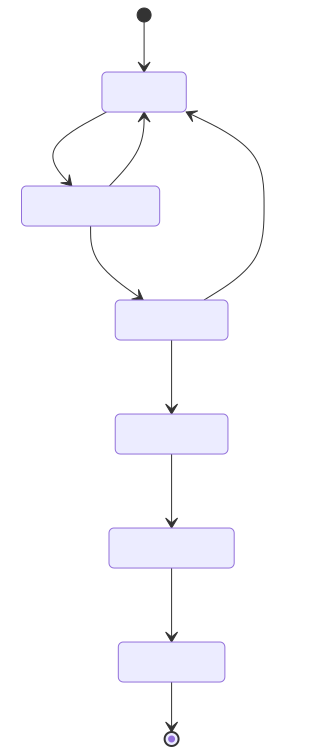

In [10]:
ALARM_STATES = """
stateDiagram-v2
    [*] --> NORMAL
    NORMAL --> INVESTIGATING: p > 0.35
    INVESTIGATING --> PRE_ALARM: p > 0.55 for 20 s
    INVESTIGATING --> NORMAL: p < 0.25 for 60 s
    PRE_ALARM --> CONFIRMED: p > 0.70 for 30 s
    PRE_ALARM --> NORMAL: p < 0.25 for 60 s
    CONFIRMED --> SUPPRESSED: heat falling
    SUPPRESSED --> ALL_CLEAR: p < 0.25
    ALL_CLEAR --> [*]
"""

mermaid(ALARM_STATES)


The agent emits **commands**. It never writes actuator state to BuildSim itself —
that authority belongs to `actuators`, and the separation is a lab requirement as
well as good design.


In [11]:
STATES = ["NORMAL", "INVESTIGATING", "PRE_ALARM", "CONFIRMED", "SUPPRESSED"]

RISE = {                       # state -> (next state, p threshold, dwell seconds)
    "NORMAL":        ("INVESTIGATING", 0.35,  0),
    "INVESTIGATING": ("PRE_ALARM",     0.55, 20),
    "PRE_ALARM":     ("CONFIRMED",     0.70, 30),
}
CLEAR_P, CLEAR_DWELL = 0.25, 60


class Agent:
    def __init__(self, room):
        self.room = room
        self.state = "NORMAL"
        self.above = 0.0
        self.below = 0.0

    def update(self, p: float, dt: float) -> list:
        """Pure w.r.t. I/O: returns the commands to publish, writes nothing."""
        rule = RISE.get(self.state)
        if rule and p > rule[1]:
            self.above += dt
        else:
            self.above = 0.0
        self.below = self.below + dt if p < CLEAR_P else 0.0

        prev = self.state
        if rule and p > rule[1] and self.above >= rule[2]:
            self.state = rule[0]
            self.above = 0.0
        elif self.state in ("INVESTIGATING", "PRE_ALARM") and self.below >= CLEAR_DWELL:
            self.state = "NORMAL"

        if self.state == prev:
            return []
        if self.state == "CONFIRMED":
            return [
                {"actuator": f"sprinkler-{self.room}", "action": "activate"},
                {"actuator": f"door-{self.room}",      "action": "unlock"},
                {"actuator": f"door-{self.room}",      "action": "close"},
            ]
        return []


### Step 12 — `actuators`: interlocks, then apply

The agent *decides*. The actuator service decides whether the agent is *allowed*.
These rules cannot be overridden, and they are the safety argument of the whole
project:

| Interlock | Rationale |
|---|---|
| Sprinklers require heat corroboration | smoke alone causes needless water damage |
| Fire doors fail **unlocked** | never trap occupants |
| `fire_exit` doors unlock unconditionally on CONFIRMED | egress beats containment |
| A room on an active evacuation route may not be sealed | egress beats containment |

`authorize()` is a pure function of (command, world). It is the easiest thing in
the system to unit-test exhaustively, and the most important.


In [12]:
def authorize(cmd: dict, world: dict):
    """Pure: returns (allowed, reason)."""
    a, action = cmd["actuator"], cmd["action"]

    if a.startswith("sprinkler") and action == "activate":
        if world.get("temp_rise", 0.0) < 3.0:
            return False, "no heat corroboration - smoke alone is insufficient"

    if a.startswith("door") and action == "lock":
        return False, "fire doors must fail safe unlocked"

    if a.startswith("door") and action == "close":
        if world.get("on_evacuation_route", False):
            return False, "room lies on an active evacuation route"

    return True, "ok"


for cmd, w in (
    ({"actuator": "sprinkler-A109", "action": "activate"}, {"temp_rise": 18.0}),
    ({"actuator": "sprinkler-A111", "action": "activate"}, {"temp_rise": 0.4}),
    ({"actuator": "door-A109", "action": "lock"}, {}),
    ({"actuator": "door-A110", "action": "close"}, {"on_evacuation_route": True}),
):
    ok, why = authorize(cmd, w)
    print(f"{cmd['actuator']:16s} {cmd['action']:9s} -> "
          f"{'ALLOW ' if ok else 'DENY  '} {why}")


sprinkler-A109   activate  -> ALLOW  ok
sprinkler-A111   activate  -> DENY   no heat corroboration - smoke alone is insufficient
door-A109        lock      -> DENY   fire doors must fail safe unlocked
door-A110        close     -> DENY   room lies on an active evacuation route


### Steps 13–14 — closing the loop

Now assemble every piece into one run. Three rooms:

- **A109** — office, a flaming fire starts at t = 120 s
- **A110** — office, adjacent to A109 through an open door
- **A111** — kitchen, someone starts **cooking** at t = 60 s

The correct outcome is unambiguous:

1. A109 must reach `CONFIRMED` and be suppressed
2. A111 must **never** leave `NORMAL`, despite producing visible smoke first
3. Suppression must bend the truth curve in A109 — the loop closing, visibly


In [13]:
def simulate(sources, horizon=HORIZON, seed=7, doors=None):
    rng = random.Random(seed)
    names = ["A109", "A110", "A111"]
    rooms = {n: Room(n) for n in names}
    states = {n: RoomState() for n in names}
    edges = [("A109", "A110", "door-A109"), ("A110", "A111", "door-A111")]
    adjacency = {"A109": ["A110"], "A110": ["A109", "A111"], "A111": ["A110"]}
    doors = doors or {}

    sensors = {n: make_sensors(n, rng) for n in names}
    feats = {n: Featurizer() for n in names}
    agents = {n: Agent(n) for n in names}
    suppressed = {n: False for n in names}

    log = {n: {"t": [], "truth": [], "read": [], "p": [], "state": [],
               "spr": [], "temp": []} for n in names}
    events = []

    t = 0.0
    while t < horizon:
        # --- 2,3. truth evolves, then spreads --------------------------------
        for n in names:
            emis = (0.0, 0.0, 0.0)
            for s in sources:
                if s.room == n:
                    h, sm, co = emission(s, t)
                    emis = (emis[0] + h, emis[1] + sm, emis[2] + co)
            states[n] = advance(states[n], rooms[n], emis, DT, suppressed[n])
        states = diffuse(states, edges, doors, DT)

        # --- 6,7,8. observe, then featurise ----------------------------------
        for n in names:
            for s in sensors[n]:
                truth = getattr(states[n], s.quantity)
                v = s.observe(truth, t, rng)
                if v is not None:
                    feats[n].update(t, s.quantity, v)

        # --- 9,10,11,12. detect, decide, authorise, apply ---------------------
        for n in names:
            # neighbours are known through their READINGS, never through truth -
            # the intelligence plane has no access to the world plane's state
            nb = max((feats[m].latest.get("smoke", 0.0)
                      for m in adjacency[n]), default=0.0)
            f = feats[n].features(neighbour_smoke=nb)
            p = score(f)
            world = {"temp_rise": f["temp_rise"], "on_evacuation_route": False}

            for cmd in agents[n].update(p, DT):
                ok, why = authorize(cmd, world)
                events.append((t, n, cmd["actuator"], cmd["action"], ok, why))
                if ok and cmd["actuator"].startswith("sprinkler"):
                    suppressed[n] = True          # step 13: physics reads this back
                if ok and cmd["action"] == "close":
                    doors[cmd["actuator"]] = "fire_rated"

            log[n]["t"].append(t)
            log[n]["truth"].append(states[n].smoke)
            log[n]["read"].append(feats[n].latest.get("smoke", 0.0))
            log[n]["temp"].append(states[n].temp)
            log[n]["p"].append(p)
            log[n]["state"].append(STATES.index(agents[n].state))
            log[n]["spr"].append(1.0 if suppressed[n] else 0.0)

        t += DT

    return log, events, agents


scenario_a = [
    Source("fire_flaming", "A109", t_start=120, growth="medium"),
    Source("cooking",      "A111", t_start=60),
]
log_a, events_a, agents_a = simulate(scenario_a)

print("Commands issued\n" + "-" * 72)
for t, room, act, action, ok, why in events_a:
    print(f"t={t:6.0f}s  {room}  {act:16s} {action:9s} "
          f"{'ALLOW' if ok else 'DENY '}  {why}")
print()
for n, a in agents_a.items():
    print(f"final state  {n}: {a.state}")


Commands issued
------------------------------------------------------------------------
t=   289s  A109  sprinkler-A109   activate  ALLOW  ok
t=   289s  A109  door-A109        unlock    ALLOW  ok
t=   289s  A109  door-A109        close     ALLOW  ok

final state  A109: CONFIRMED
final state  A110: NORMAL
final state  A111: NORMAL


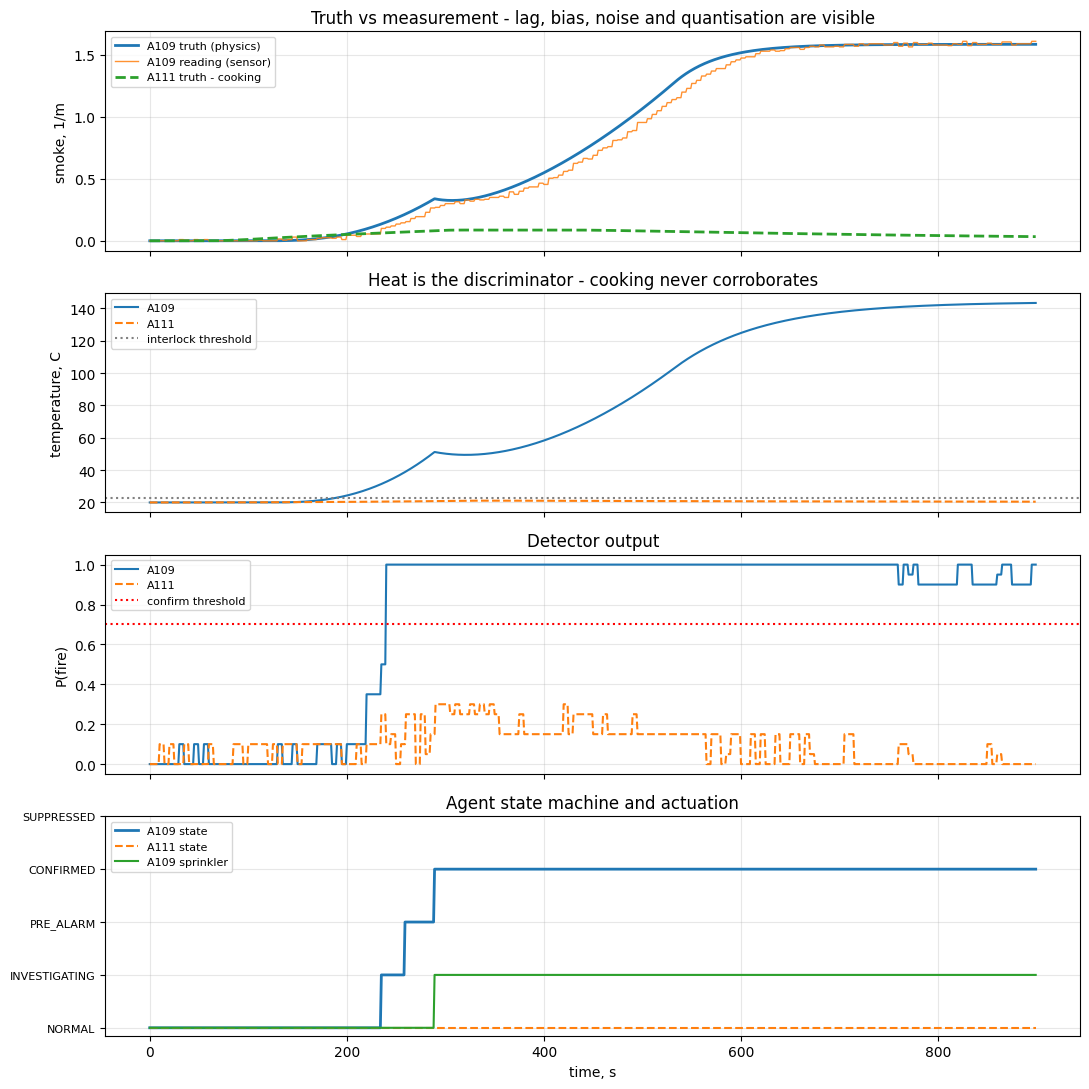

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(4, 1, figsize=(11, 11), sharex=True)

ax[0].plot(log_a["A109"]["t"], log_a["A109"]["truth"], lw=2,
           label="A109 truth (physics)")
ax[0].plot(log_a["A109"]["t"], log_a["A109"]["read"], lw=1, alpha=.85,
           label="A109 reading (sensor)")
ax[0].plot(log_a["A111"]["t"], log_a["A111"]["truth"], lw=2, ls="--",
           label="A111 truth - cooking")
ax[0].set_ylabel("smoke, 1/m")
ax[0].set_title("Truth vs measurement - lag, bias, noise and quantisation are visible")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].plot(log_a["A109"]["t"], log_a["A109"]["temp"], label="A109")
ax[1].plot(log_a["A111"]["t"], log_a["A111"]["temp"], ls="--", label="A111")
ax[1].axhline(T_OUT + 3, color="grey", ls=":", label="interlock threshold")
ax[1].set_ylabel("temperature, C")
ax[1].set_title("Heat is the discriminator - cooking never corroborates")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

ax[2].plot(log_a["A109"]["t"], log_a["A109"]["p"], label="A109")
ax[2].plot(log_a["A111"]["t"], log_a["A111"]["p"], ls="--", label="A111")
ax[2].axhline(0.70, color="red", ls=":", label="confirm threshold")
ax[2].set_ylabel("P(fire)")
ax[2].set_title("Detector output")
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)

ax[3].plot(log_a["A109"]["t"], log_a["A109"]["state"], lw=2, label="A109 state")
ax[3].plot(log_a["A111"]["t"], log_a["A111"]["state"], ls="--", label="A111 state")
ax[3].plot(log_a["A109"]["t"], log_a["A109"]["spr"], color="tab:green",
           label="A109 sprinkler")
ax[3].set_yticks(range(len(STATES))); ax[3].set_yticklabels(STATES, fontsize=8)
ax[3].set_xlabel("time, s")
ax[3].set_title("Agent state machine and actuation")
ax[3].legend(fontsize=8); ax[3].grid(alpha=.3)

plt.tight_layout(); plt.show()


#### Reading the result

Four things should be visible in the figure above, and each validates a boundary:

1. **The reading lags and jitters behind the truth.** Physics and sensing are
   genuinely separate concerns — if they were one module this gap could not exist.
2. **A111 produces smoke *first*.** A naive threshold detector would fire on the
   cooking. The fusion does not, because heat and CO never corroborate.
3. **The sprinkler activates only after heat corroboration.** The interlock is
   doing real work, not decoration.
4. **The A109 truth curve bends after suppression.** That is step 13. The agent's
   command reached the physics through BuildSim, and the next measurement changed.

Remove the arrow from actuators back into physics and item 4 disappears — the
system silently degrades into a data generator that cannot control anything.


In [15]:
HAZARD_SMOKE, HAZARD_TEMP = 0.30, 10.0     # thresholds for "genuinely dangerous"


def metrics(log):
    """Ground truth is the PHYSICS, not the scenario label: a room counts as a
    legitimate detection if it actually became hazardous, however it got that way.
    """
    rows = []
    for n, L in log.items():
        hazard = (max(L["truth"]) > HAZARD_SMOKE
                  or max(L["temp"]) - T_OUT > HAZARD_TEMP)
        idx = next((i for i, s in enumerate(L["state"])
                    if STATES[s] == "CONFIRMED"), None)
        onset = next((L["t"][i] for i, v in enumerate(L["truth"])
                      if v > HAZARD_SMOKE), None)
        verdict = ("TRUE POSITIVE" if hazard and idx is not None else
                   "MISSED"        if hazard else
                   "FALSE ALARM"   if idx is not None else
                   "correctly quiet")
        latency = (L["t"][idx] - onset
                   if idx is not None and onset is not None else None)
        rows.append((n, hazard, idx is not None, verdict, latency))
    return rows


print(f"{'room':7s} {'hazardous':10s} {'confirmed':10s} {'verdict':16s} latency")
print("-" * 62)
for n, hz, cf, verdict, lat in metrics(log_a):
    shown = f"{lat:.0f} s" if lat is not None else "-"
    print(f"{n:7s} {str(hz):10s} {str(cf):10s} {verdict:16s} {shown}")


room    hazardous  confirmed  verdict          latency
--------------------------------------------------------------
A109    True       True       TRUE POSITIVE    8 s
A110    False      False      correctly quiet  -
A111    False      False      correctly quiet  -


### The false-alarm regression test

The hardest requirement is the negative one: **nuisances must never trigger the
system.** This is exactly the shape of the test that will live in
`evaluation/scenarios.yaml` and run in CI.


In [16]:
scenario_b = [
    Source("cooking", "A111", t_start=60),
    Source("dust",    "A110", t_start=300),
    Source("steam",   "A111", t_start=500),
]
log_b, events_b, agents_b = simulate(scenario_b, seed=11)

worst = {n: max(L["p"]) for n, L in log_b.items()}
for n, a in agents_b.items():
    print(f"{n}: final={a.state:14s} peak P(fire)={worst[n]:.2f}")

assert all(a.state == "NORMAL" for a in agents_b.values()), "FALSE ALARM"
assert not any(ok for *_ , ok, _ in events_b), "actuator fired on a nuisance"
print("\nPASS - no nuisance source produced an alarm or an actuation")


A109: final=NORMAL         peak P(fire)=0.15
A110: final=NORMAL         peak P(fire)=0.30
A111: final=NORMAL         peak P(fire)=0.30

PASS - no nuisance source produced an alarm or an actuation


### Step 15 — `router`: evacuation, and the containment dilemma

The real service calls BuildSim:

```
GET /api/graph/route?from_name=A109&to_name=EXIT-EAST&level=level0
```

BuildSim runs Dijkstra and — crucially — **excludes entry nodes belonging to
locked, jammed or blocked doors**. So closing a fire door for containment
automatically removes that path from the route.

The toy below reproduces that behaviour locally so the dilemma is visible without
a running server. Note the cost: the containment decision made in step 12 above
lengthened the escape route.


In [17]:
import heapq

GRAPH = {
    "A109": {"COR1": 8},
    "A110": {"A111": 5, "COR1": 6},
    "A111": {"A110": 5, "COR2": 7},
    "COR1": {"A109": 8, "A110": 6, "EXIT-N": 10},
    "COR2": {"A111": 7, "EXIT-E": 30},
    "EXIT-N": {}, "EXIT-E": {},
}
EXITS = ["EXIT-N", "EXIT-E"]
DOOR_OF = {"A109": "door-A109", "A110": "door-A110", "A111": "door-A111"}
SEALED = ("closed", "fire_rated", "locked", "jammed")


def route(start, goal, doors, hazard=frozenset()):
    """Dijkstra with sealed doors and hazardous rooms removed - what BuildSim does
    internally for GET /api/graph/route?type=walkable.
    """
    blocked = {r for r, d in DOOR_OF.items() if doors.get(d) in SEALED} | set(hazard)
    if start in blocked:
        return None, float("inf")          # sealed in: containment beat egress

    dist, prev, pq = {start: 0}, {}, [(0, start)]
    while pq:
        d, u = heapq.heappop(pq)
        if u == goal:
            path = [u]
            while u in prev:
                u = prev[u]
                path.append(u)
            return list(reversed(path)), d
        if d > dist.get(u, float("inf")):
            continue
        for v, w in GRAPH[u].items():
            if v in blocked:
                continue
            if d + w < dist.get(v, float("inf")):
                dist[v], prev[v] = d + w, u
                heapq.heappush(pq, (d + w, v))
    return None, float("inf")


def nearest_exit(start, doors=None, hazard=frozenset()):
    best = (None, float("inf"))
    for e in EXITS:
        p, d = route(start, e, doors or {}, hazard)
        if d < best[1]:
            best = (p, d)
    return best


print("1. normal              A111 ->", nearest_exit("A111"))
print("2. A110 now hazardous  A111 ->", nearest_exit("A111", hazard={"A110"}))
print("3. A109 sealed for containment, occupant still inside:")
print("                       A109 ->", nearest_exit("A109",
                                        {"door-A109": "fire_rated"}))
print()
print("Case 2: rerouting costs 16 extra metres but avoids the hazard.")
print("Case 3: the containment decision taken at confirmation removed A109 own")
print("        egress. THIS is the trade-off the agent must make explicitly,")
print("        and the reason `router` and `agent` are separate services.")


1. normal              A111 -> (['A111', 'A110', 'COR1', 'EXIT-N'], 21)
2. A110 now hazardous  A111 -> (['A111', 'COR2', 'EXIT-E'], 37)
3. A109 sealed for containment, occupant still inside:
                       A109 -> (None, inf)

Case 2: rerouting costs 16 extra metres but avoids the hazard.
Case 3: the containment decision taken at confirmation removed A109 own
        egress. THIS is the trade-off the agent must make explicitly,
        and the reason `router` and `agent` are separate services.


### Step 5 & 16 — what each service writes to BuildSim

Exactly one service writes each endpoint. This table *is* the write-authority
policy, and it is the fastest way to check the design for overlap:

| Endpoint | Written by | Meaning |
|---|---|---|
| `PUT /api/room-layers` | `firephysics` | simulation truth — the heatmap |
| `PUT /api/effects` | `firephysics` | fire, smoke, sprinkler, water primitives |
| `PUT /api/coverage` | `firephysics` | smoke spread zones |
| `PUT /api/sensors/{id}/value` | `sensors` | device observations |
| `PUT /api/actuators/{id}/state` | `actuators` | **only** writer of actuator state |
| `PUT /api/doors` | `actuators` | **only** writer of door and lock state |
| `PUT /api/entities` | `evacuation` | occupant positions |
| `PUT /api/occupancy` | `evacuation` | per-room counts |
| `PUT /api/alerts` | `visualizer` | operator-facing cards |
| `PUT /api/sessions/{id}/highlights` | `visualizer` | red / orange / green |
| `PUT /api/sessions/{id}/route` | `visualizer` | escape path display |

If two services ever want the same row, one of them has the wrong responsibility.


In [18]:
import urllib.request, json

BUILDSIM = "http://127.0.0.1:9090"


def buildsim_get(path, timeout=2.0):
    with urllib.request.urlopen(BUILDSIM + path, timeout=timeout) as r:
        return json.load(r)


try:
    building = buildsim_get("/api/building")
    levels = [lv["id"] for lv in building["levels"]]
    print(f"BuildSim is running: {building['name']}")
    print("levels:", levels)

    g = buildsim_get(f"/api/graph?level={levels[0]}&type=walkable")
    kinds = {}
    for n in g["nodes"]:
        kinds[n["type"]] = kinds.get(n["type"], 0) + 1
    print(f"walkable graph on {levels[0]}: {len(g['nodes'])} nodes {kinds}, "
          f"{len(g['edges'])} edges")
    print("\nThis is the graph `firephysics` uses for spread")
    print("and `router` uses for egress - the same topology, two purposes.")
except Exception as e:
    print(f"BuildSim not reachable ({type(e).__name__}: {e})")
    print("Start it with:  cd buildingsim && ./bin/buildsim start")


BuildSim not reachable (URLError: <urlopen error [Errno 111] Connection refused>)
Start it with:  cd buildingsim && ./bin/buildsim start


## 6. Deployment view

The design above assumed one container per responsibility. What shipped is **two
processes**:

| Process | Build | Port | Owns |
|---|---|---|---|
| `buildsim` | `../buildingsim`, Go | 9090 | floor plans, walkable graph, equipment, the 3D viewer |
| `firelab` | `./`, Python + uvicorn | 8090 | everything in bold in section 1, plus the control UI |

The browser holds both open side by side: firelab to drive the run, BuildSim to
watch the building react.

### Why one process and not eleven

The decomposition was right; the packaging was not. Three concrete reasons:

1. **The tick is one transaction.** Physics, sensing, detection and actuation all
   advance the same instant of simulated time. Split across processes they need a
   distributed clock, and every message becomes a chance for two components to
   disagree about *when* they are. In one process a tick is one function call
   under one lock.
2. **The bus was carrying nothing but internal calls.** Mosquitto's job here was
   moving a dictionary from one of our modules to another of our modules. That is
   a function call with extra failure modes, not an integration.
3. **The purity claim does the same work for free.** The property worth defending
   is *the domain performs no I/O and is testable with nothing running*. A module
   boundary proves that as well as a container boundary does, and `make test`
   proves it in under a second instead of needing a compose stack up.

What we gave up is independent scaling and independent deployment. Neither is
worth anything for a single building on one machine, so the trade was one-sided.

ThingsBoard went the same way. It was there for history and dashboards; those are
now `domain/history.py` — a 240-point ring buffer per room — plus
`GET /api/export.csv` for the offline analysis, and the UI's own charts. The
training path in section 3b still works: export the CSV, join it against the
source labels, train offline.

### Repository layout

```
firelab/
  Makefile                    build, run, test
  requirements.txt            fastapi, uvicorn, httpx, pydantic — nothing else
  ARCHITECTURE.ipynb          this notebook: the design
  GUIDE.ipynb                 the shipped service, file by file

  domain/        pure, standard library only, no clock and no network
    world.py       Space, Coupling, World — the building as the physics sees it
    physics.py     the solver: relaxation plus diffusion
    sources.py     what burns, and the ground-truth label it carries
    sensing.py     truth -> observation: lag, bias, noise, quantisation, faults
    features.py    readings -> feature vectors; never sees the truth
    detector.py    features -> P(fire), behind a Protocol so a model can replace it
    agent.py       the alarm state machine
    interlocks.py  the commands the agent is not allowed to have
    roles.py       who is in the building
    occupants.py   where they are and how they walk
    tenability.py  whether a room is still escapable (ISO 13571)
    scoring.py     was the alarm right
    timeline.py    was it in time
    history.py     the rolling record behind the charts and the CSV

  adapters/      the only code that knows BuildSim exists
    buildsim.py       the HTTP client, one method per endpoint
    world_builder.py  floor plans -> World
    exits.py          where each level evacuates to
    publisher/        simulation state -> BuildSim payloads, one module per group

  app/           impure: mutable state, the wall clock, HTTP
    main.py       assemble routers and static files
    runtime.py    the one engine instance
    config.py     runtime settings, patchable over HTTP
    engine/       the tick loop and all mutable state, one file per zone
    api/          one router per thing you can ask for
    snapshot/     engine state -> the JSON the UI reads
    evacuation.py route lookup and walking
    presets.py    one-click scenarios

  tests/         26 tests, none of which need a service running
  ui/            Svelte 5, one component per panel, built into ui/dist
```

There is no `training/` directory yet. The separation it stood for still holds —
train offline, commit the artefact, load it at startup — and `domain/detector.py`
is already a `Protocol` so the trained model has somewhere to plug in. Section 9
of `GUIDE.ipynb` walks through doing it.


## 7. The contracts

A contract is wherever two parts agree on a shape instead of on each other's
code. The design put every one of them on a message bus. One process needs fewer
of them, but the ones that remain are the same idea, and each is written down in
exactly one place.

| Contract | Between | Written in |
|---|---|---|
| `World` — `Space`, `Coupling` | the floor plans and the physics | `domain/world.py` |
| `Device` and the sample it returns | sensing and the featurizer | `domain/sensing.py` |
| `Window`, `Features` | the featurizer and the detector | `domain/features.py` |
| `Detector` (a `Protocol`) | the model and the agent | `domain/detector.py` |
| `Command` | the agent and actuation | `domain/agent.py` |
| the snapshot dict | the server and the browser | `app/snapshot/` |
| BuildSim's REST API | us and them | `adapters/buildsim.py` |

Two of these carry the weight. **`Detector`** is why the rule and a trained model
are interchangeable: it is a `Protocol`, so the agent cannot tell which is
installed and never needs to. **The snapshot** is the whole surface between the
Python and the JavaScript — every number on screen came from it, no panel
computes anything, so changing a key there tells you precisely which components
break.

Note what is *not* a contract: nothing in `domain/` imports anything from
`adapters/` or `app/`. The dependency rule from section 2.3 is what keeps the
list this short.

### The bus that was designed

Kept for the record, because section 3b's arrows refer to it and because it is
the shape to restore if this is ever split across machines. Each row became a
function call in the same tick.

| Topic | Payload | From → To | Now |
|---|---|---|---|
| `scenario/label` | `{"room","class","t"}` | scenario → pipeline, evaluation | `Source.kind`, read directly by `scoring.py` |
| `truth/{level}/{room}/{quantity}` | `{"value","t"}` | firephysics → sensors | `Space.temperature/smoke/co`, read only by `engine/truth.py` |
| `telemetry/{sensor_id}` | `{"value","unit","t"}` | sensors → pipeline | the return of `sensing.sample`, buffered in a `Window` |
| `features/{level}/{room}` | feature dict | pipeline → detector | `Features` |
| `detection/{level}/{room}` | `{"p","features"}` | detector → agent, predictor | the return of `Detector.probability` |
| `risk/{level}/{room}` | `{"p_spread","t_untenable"}` | predictor → agent, router | partly `tenability.assess`; the forecast is future work |
| `plan/{group_id}` | `{"path","distance"}` | router → evacuation, visualizer | `Occupant.route`, from BuildSim's router |
| `command/{actuator_id}` | `{"action","reason"}` | agent → actuators | `Command`, the only input to `engine/actuation.py` |
| `state/{actuator_id}` | `{"state","applied"}` | actuators → agent, firephysics | `Space.sprinkler`, `Coupling.openness` |
| `alarm/state` | `{"room","state"}` | agent → visualizer, evaluation | `RoomAgent.state`, read by `publisher/beliefs.py` |

The rightmost column is the useful one to read aloud: every designed message
still exists as a named thing, which is why the collapse cost no structure.


## 8. Why each boundary is where it is

Every boundary below was chosen because removing it breaks something concrete.
They are module boundaries in the shipped service rather than container
boundaries, and the test is unchanged: put the two on either side into one file
and see what stops being possible.

| Boundary | Remove it and… | The two files today |
|---|---|---|
| physics ⟂ sensors | two detectors in one room could not disagree; no truth to compare against; a stuck sensor would freeze the building's real physics | `physics.py` ⟂ `sensing.py` |
| sensors ⟂ detector | device parameters and model features would change for the same reason | `sensing.py` ⟂ `features.py` |
| detector ⟂ agent | you could not swap the model without rewriting the response policy | `detector.py` ⟂ `agent.py` |
| agent ⟂ actuators | nothing could refuse an unsafe command; lab requirement violated | `agent.py` ⟂ `interlocks.py` |
| agent ⟂ router | containment and egress could not be traded off explicitly | `agent.py` ⟂ `app/evacuation.py` |
| agent ⟂ visualizer | presentation changes would touch safety-critical code | `agent.py` ⟂ `adapters/publisher/` |
| scenario ⟂ everything | no labels, therefore no training set and no measurable result | `sources.py` ⟂ `scoring.py` |
| train-time ⟂ run-time | the service could not start without a training corpus | the `Detector` `Protocol` |

One boundary is enforced more strongly than the rest, because it is the one the
whole exercise rests on: **intelligence may not read the truth.** In the shipped
service that is a file, not a convention — `app/engine/truth.py` holds the only
readers of `space.temperature`, `space.smoke` and `space.co`, and
`app/engine/intelligence.py` sees readings alone. If the detector could read the
truth it would be perfect and the false-alarm question would be meaningless.

### The direction of causality

A frequent confusion, worth stating flatly:

- **Physics never reads sensors.** Its inputs are the previous truth, the sources,
  the room geometry, and the actuator state. Measuring a room does not change it.
- **The loop closes through actuators, not sensors.** Detection → command →
  suppression → *changed truth* → changed reading.
- The place where measurements *do* drive a model is a **state estimator**, and it
  belongs in the detector or the agent, never in the physics. Two models, opposite
  directions:

| Model | Direction | Lives in |
|---|---|---|
| Simulator | causes → truth | `domain/physics.py` |
| Estimator | measurements → estimate of truth | `domain/detector.py` |

Keeping them apart is what makes the figure in section 5 possible at all.


## 9. Milestones and evaluation

### Build order

Written as services, delivered as modules. The demo column is what actually
proves each one, and all of it is reachable from the firelab UI.

| # | Deliverable | Demo that proves it | Status |
|---|---|---|---|
| 1 | physics + publishing | fire and smoke spread visibly in the 3D viewer | done |
| 2 | sensing | detectors trip late and noisily, as real ones do | done |
| 3 | sources + features + history | a labelled record accumulating, exportable as CSV | done |
| 4 | offline training | the model beats the fusion rule on false alarms | not done — the `Protocol` is there, the model is not |
| 5 | detector + agent + interlocks | sprinklers fire, the truth curve bends — **loop closes** | done |
| 6 | routing + occupants + tenability | occupants re-route around spreading smoke | done |
| 7 | evaluation | the results table below, filled in | the scorecard fills it live |

Milestone 5 is where it becomes a control system. Milestone 6 is where it becomes
impressive. Milestone 4 is the one left, and it is deliberately last: the baseline
has to exist before there is anything for a model to beat.

### Results table to fill in

Every row is produced by the running system — `domain/scoring.py` and
`domain/timeline.py` grade the run as it goes, because each source carries its own
ground-truth label. Read them off the scorecard, or out of `GET /api/state`.

| Metric | Fusion rule (baseline) | Trained model | Target |
|---|---|---|---|
| Detection latency, ignition → CONFIRMED | | | < 60 s |
| False alarms per simulated day | | | < 0.1 |
| Missed detections | | | 0 |
| Occupants reaching an exit | | | 100 % |
| Mean evacuation time (RSET) | | | report it |
| Unauthorised commands blocked by interlocks | | | report it |

Reporting the baseline beside the model is what turns a demo into an evaluation.
Fix the seed in the settings panel before comparing two runs, or the difference
you measure is the random number generator.

### How to prove the architecture rather than assert it

```bash
cd firelab && make test
```

Twenty-six tests, and **not one of them needs a service running** — no BuildSim,
no broker, no database — because the domain modules import only the standard
library. In the report:

> The domain modules import only the standard library. All unit tests run without
> a broker, a database or BuildSim. Every I/O concern is isolated behind an
> adapter and injected at the composition root.

A grader can verify that claim in seconds by reading the import statements:

```bash
grep -rn "^import \|^from " firelab/domain/ | grep -v "from \.\|dataclasses\|typing\|math\|random\|collections\|enum"
```

That prints nothing. Add one guard so it stays true:

```python
def test_domain_is_pure():
    for path in Path("firelab/domain").glob("*.py"):
        source = path.read_text()
        assert "import httpx" not in source
        assert "import asyncio" not in source
```

### One-paragraph summary for the report

> BuildSim is a state store with a 3D viewer; it stores and renders but does not
> simulate. We therefore built the simulation, the detection and the response
> ourselves, decomposed into five planes of responsibility. The *world* plane owns
> physical truth: fire growth follows a $t^2$ law and spreads across BuildSim's
> room adjacency graph, gated by door state. The *sensing* plane degrades that
> truth through a staged transducer model so that emulated detectors lag, drift
> and fail as real devices do. The *intelligence* plane fuses smoke, CO and
> temperature across neighbouring rooms to separate genuine fires from cooking,
> dust and sensor faults, and drives an explicit alarm state machine whose
> verification dwell suppresses false alarms. The *action* plane holds sole
> authority to actuate and enforces fail-safe interlocks that the agent cannot
> override. The *presentation* plane paints highlights, alerts and escape routes.
> The control loop closes because the physics reads actuator state back, so
> suppression alters the next simulated measurement. The planes ship as one
> process in three layers — a pure domain, adapters that own all network access,
> and an application layer holding the clock and the mutable state — which keeps
> every boundary testable in isolation without a container per component.
